## Logan contigs processing
This record spans from:

1. downloading the output Logan contigs from AWS
2. extracting the nucleotide sequence hits
3. finding stop-stop ORFs, and
4. characterizing said orfs with HMMs

In [ ]:
#versions and stuff
zstd --version
#*** Zstandard CLI (64-bit) v1.5.5, by Yann Collet ***
awk --version
#GNU Awk 5.1.0, API: 3.0 (GNU MPFR 4.1.0-p9, GNU MP 6.2.0)
grep --version
#grep (GNU grep) 3.6
seqkit version
#seqkit v2.8.0
getorf -version
#EMBOSS:6.6.0.0
hmmsearch -h
# hmmsearch :: search profile(s) against a sequence database
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

In [2]:
getwd()

[1] "/home/jshen"

## P1 downloading the output Logan contigs from AWS
Nothing too much of note here :)


In [ ]:
%%sh
#p1, downloading output from Logan (this may take a while)
#download from s3
aws s3 sync s3://serratus-rayan/beetles/logan_feb6_run/diamond-concat/papilloma/ .
#decompress and concat
zstd -dc *.zst > feb_7_pv.pro
#filter for e< 10^-10
awk '($11 + 0.0 < 0.0000000001) {print}' feb_7_pv.pro > feb_7_pv_fil.pr


## P2 getting nucleotide sequence hits
Take advantage of bash here, set output field seps as tab, seqkit tab2fx is your best friend


In [ ]:
%%sh
#p2, get the nucleotide sequences by taking advantage of seqkit tab2fx :)
awk 'OFS="\t" {print $1, $14}' feb_7_pv_fil.pro | seqkit tab2fx > feb_7_pv_fil.nuc
#sanity check
grep -A5 ">" feb_7_pv_fil.nuc | head -n20

# >DRR000743_10070_ka:f:57.108_L:-:203283:-_L:+:203283:+_
# GTTGAATACTCATACTCTTCCTTTTTCAATATTATTGAAGCATTTATCAGGGTTATTGTC
# TCATGAGCGGATACATATTTGAATGTATTTAGAAAAATAAACAAATAGGGGTTCCGCGCA
# CATTTCCCCGAAAAGTGCCACCTGACGTCTAAGAAACCATTATTATCATGACATTAACCT
# ATAAAAATAGGCGTATCACGAGGCCCTTTCGTCTTCAAGAATTCTCATGTTTGACAGCTT
# ATCATCGATAAGCTTTAATGCGGTAGTTTATCACAGTTAAATTGCTAACGCAGTCAGGCA
# --
# >DRR000865_1027_ka:f:7.291_
# GCATAGTTATTAATAGCAGACACTCTATGCCTGTGTGGAGTAAGAAAAAACAGTATGTTA
# TGATTATAACTGTTATGCCTACTTATAAAGGTTACAGAATATTTTTCCATAATTTTTTTG
# TATAGCAGTGCAGCTTTTTCCTTTGTGGTGTAAATAGCAAAGCAAGCAAGAGTTCTATTA
# CTAAACACAGCATGACTCAAAAAACTTAGCAATTCTGAAGGAAAGTCCTTGGGGTCTTCT
# ACCTTTCTCTTCTTTTTTGGAGGAGTAGA
# >DRR000865_13869_ka:f:6.019_
# CCGCCGCCGCAAGGAATGGTGCATGCAAGGAGATGGCGCCCAACAGTCCCCCGGCCACGG
# GGCCTGCCACCATACCCACGCCGAAACAAGCGCTCATGAGCCCGAAGTGGCGAGCCCGAT
# CTTCCCCATCGGTGATGTCGGCGATATAGGCGCCAGCAACCGCACCTGT
# >DRR000892_1154_ka:f:15.487_
# CCGCCACTACATACATTGCCGCCATGTTCGCCATTTGTAGTTACCTGATTCTGTGTTGCT
# TCCACTTCAGAACAGCCATAGCCACTATCTGATATTGTAAACAGCCGCCTTTTTGCCTTT

#ok nice

## P3 finding stop-stop orfs
emboss getorf truncates sequence names when faced with special characters, from the Logan output : and + are issues. it's ok to strip them at this point, since contig information can be retrieved using the contig_library designation anyways if needed. stop-stop is used here, since there seemed to be some evidence that PVs can use alternate start codons, and on top of that, the region of L1 of interest in might not necessarily start with a start codon.

rough powerpoint representation of what i mean:

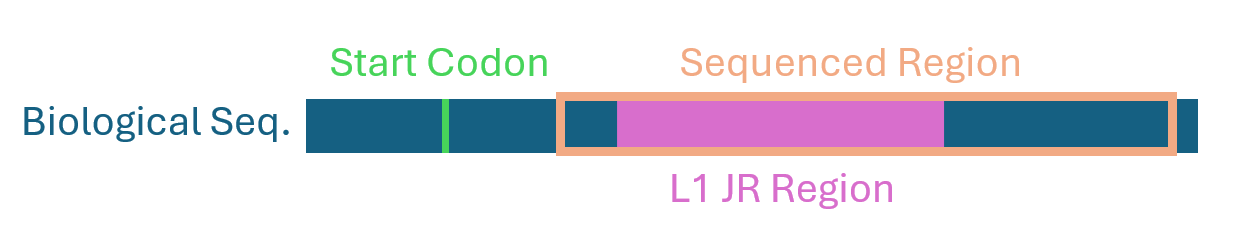

In [ ]:
%%sh
#p3, get the stop-stop orfs, using emboss getorf
#getorf does not play well with some special characters, so they need to be stripped, and formatted to look less ugly
#this takes a lil while
sed -e 's/[:+-]/_/g' -e 's/___/_/g' feb_7_pv_fil.nuc > feb_7_pv_fil_form.nuc
grep -A5 ">" eb_7_pv_fil_form.nuc | head -n20
# >DRR000743_10070_ka_f_57.108_L_203283_L_203283_
# GTTGAATACTCATACTCTTCCTTTTTCAATATTATTGAAGCATTTATCAGGGTTATTGTC
# TCATGAGCGGATACATATTTGAATGTATTTAGAAAAATAAACAAATAGGGGTTCCGCGCA
# CATTTCCCCGAAAAGTGCCACCTGACGTCTAAGAAACCATTATTATCATGACATTAACCT
# ATAAAAATAGGCGTATCACGAGGCCCTTTCGTCTTCAAGAATTCTCATGTTTGACAGCTT
# ATCATCGATAAGCTTTAATGCGGTAGTTTATCACAGTTAAATTGCTAACGCAGTCAGGCA
# --
# >DRR000865_1027_ka_f_7.291_
# GCATAGTTATTAATAGCAGACACTCTATGCCTGTGTGGAGTAAGAAAAAACAGTATGTTA
# TGATTATAACTGTTATGCCTACTTATAAAGGTTACAGAATATTTTTCCATAATTTTTTTG
# TATAGCAGTGCAGCTTTTTCCTTTGTGGTGTAAATAGCAAAGCAAGCAAGAGTTCTATTA
# CTAAACACAGCATGACTCAAAAAACTTAGCAATTCTGAAGGAAAGTCCTTGGGGTCTTCT
# ACCTTTCTCTTCTTTTTTGGAGGAGTAGA
# >DRR000865_13869_ka_f_6.019_
# CCGCCGCCGCAAGGAATGGTGCATGCAAGGAGATGGCGCCCAACAGTCCCCCGGCCACGG
# GGCCTGCCACCATACCCACGCCGAAACAAGCGCTCATGAGCCCGAAGTGGCGAGCCCGAT
# CTTCCCCATCGGTGATGTCGGCGATATAGGCGCCAGCAACCGCACCTGT
# >DRR000892_1154_ka_f_15.487_
# CCGCCACTACATACATTGCCGCCATGTTCGCCATTTGTAGTTACCTGATTCTGTGTTGCT
# TCCACTTCAGAACAGCCATAGCCACTATCTGATATTGTAAACAGCCGCCTTTTTGCCTTT

#ok nice

#use stop-stop orf finding from emboss, this will also take a bit (for real)
getorf -sequence feb_7_pv_fil_form.nuc -outseq feb_7_pv_fil_form.aa -find 0  




## P4 characterizing orfs with HMMs
use the premade pfam models to identify what each gene is. also run the in-house L1 model that i generated from the first few Logan runs, and NCBI (as a comparison for my curiosity)

In [ ]:
%%sh
#p3, characterizing orfs with HMMs
#generate the PVfam HMM, using Pfam entries
#download these from webserver
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00513/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00511/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00519/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00500/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00508/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00509/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00518/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF20450/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF02711/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00524/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF03025/logo/
#https://www.ebi.ac.uk/interpro/entry/pfam/PF00527/logo/

#unzip and combine into a giant profile
gunzip *.gz
cat *.hmm > PVfam_full
#add in-house updated L1 hmm, see hmm folder for process and files
cat PVfam_full ncbi_and_novel_L1_JR.hmm > PVfam_ncbi_novel.hmm
#run hmmsearch with fairly default params, output as table wahoo
hmmsearch --F1 0.01 -T 20 --domtblout feb_7_pv_fil_form.aa.domtbl PVfam_ncbi_novel.hmm feb_7_pv_fil_form.aa

## now have the annotated ORFs from the Logan output, wahoo!
see next section (2024.02.07.statistics_and_interpretation) for downstream analysis.